# Cross-Run Manifold Analysis: Testing Generalization Across Actuation Frequencies

## 1. Motivation

The preceding analyses in this thesis have established that the velocity-field snapshots of a forced turbulent jet lie on a low-dimensional manifold whose geometry is governed by the actuation phase. However, all evidence so far is confined to a **single** operating condition (RUN 2, $St_{act} = 0.05$).

A stronger claim of the Manifold Hypothesis requires demonstrating that the manifold structure **generalizes** across different actuation frequencies. Specifically: if two jets are forced at different Strouhal numbers $St_A$ and $St_B$, do their coherent vortex-ring patterns occupy the same region of the high-dimensional state space? If snapshots from both runs are mixed when clustered jointly, the spatial topology of the dominant coherent structures is invariant to the forcing frequency—a result with significant implications for flow-control design.

## 2. Objectives

This notebook addresses the following question:

$$\text{Is the manifold geometry invariant to the forcing frequency?}$$

We pursue this by:
1. Loading fluctuating velocity snapshots from **RUN 1** ($St_{act} = 0$, natural/unforced jet) and **RUN 2** ($St_{act} = 0.05$, forced jet).
2. Concatenating both datasets into a single snapshot matrix.
3. Applying PCA for dimensionality reduction.
4. Clustering the combined PCA scores with hierarchical clustering (Ward linkage).
5. Analysing the run composition of each cluster to determine whether clusters separate by run (distinct manifolds) or mix (shared manifold).

---

In [1]:
# ============================================================
# Section 2: Imports and Configuration
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import cosine as cosine_distance

# --- Plotting defaults (publication quality) ---
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

# --- Run information (from data/info.txt) ---
# RUN 1: St_act = 0     (unforced / natural jet)
# RUN 2: St_act = 0.05  (forced jet)
RUN_IDS = [1, 2]
ST_ACT  = {1: 0.0, 2: 0.05}

# Spatial subsampling factor (consistent with intrinsic_dimension.ipynb)
# This reduces the feature dimension from ~171 622 to ~43 200,
# making the analysis tractable without losing global topology.
SUBSAMPLE = (2, 2)

print("Imports complete.")

Imports complete.


## 3. Helper Functions

Per the parallel-execution rules of this project, all helper utilities are reimplemented locally within this notebook. No existing `.py` files are modified.

In [2]:
# ============================================================
# Helper: make_matrix
# Converts PIV snapshots (u, v) into a 2D feature matrix.
# Reimplemented from intrinsic_dimension.ipynb.
# ============================================================
def make_matrix(u, v, subsample=None):
    """
    Flatten and concatenate velocity components into a snapshot matrix.

    Parameters
    ----------
    u, v : np.ndarray, shape (n_snapshots, Ny, Nx)
        Fluctuating velocity components.
    subsample : tuple (sy, sx), optional
        Spatial subsampling factors to reduce dimensionality.

    Returns
    -------
    X : np.ndarray, shape (n_snapshots, n_features)
        The data matrix where n_features = 2 * n_valid_pixels.
    """
    n_snap, Ny, Nx = u.shape

    # 1. Identify valid (non-NaN) pixels
    valid_pixels = np.isfinite(u).all(axis=0) & np.isfinite(v).all(axis=0)

    # 2. Apply subsampling mask if requested
    if subsample is not None:
        sy, sx = subsample
        grid_sub = np.zeros_like(valid_pixels, dtype=bool)
        grid_sub[::sy, ::sx] = True
        valid_pixels &= grid_sub

    # 3. Get linear indices of valid pixels
    idx_valid = np.flatnonzero(valid_pixels)
    if idx_valid.size == 0:
        raise ValueError("No valid features after masking.")

    # 4. Flatten spatial dims and select valid columns
    u_flat = u.reshape(n_snap, -1)[:, idx_valid]
    v_flat = v.reshape(n_snap, -1)[:, idx_valid]

    # 5. Concatenate [u_1,...,u_k, v_1,...,v_k]
    X = np.hstack([u_flat, v_flat])

    print(f"  Snapshots: {n_snap}, Spatial points: {idx_valid.size}, "
          f"Total features (p): {X.shape[1]}")
    return X.astype(np.float32)


# ============================================================
# Helper: plot_velocity_field
# Visualises a 2D velocity field (contour + quiver).
# Reimplemented from data_utils.py with publication-quality defaults.
# ============================================================
def plot_velocity_field(X, Y, uc, vc, title=None,
                        scale=20, quiver_step=5, cmap="RdBu_r",
                        save_path=None):
    """
    Contour + quiver plot of a velocity field.

    Parameters
    ----------
    X, Y : np.ndarray, shape (Ny, Nx)
        Spatial coordinate meshgrids.
    uc, vc : np.ndarray, shape (Ny, Nx)
        Horizontal and vertical velocity components.
    title : str, optional
    scale : float
        Quiver arrow scale.
    quiver_step : int
        Subsampling for quiver arrows.
    cmap : str
    save_path : str, optional
        If given, save figure to this path.
    """
    # Compute velocity magnitude for colouring
    mag = np.sqrt(uc**2 + vc**2)

    fig, ax = plt.subplots(figsize=(10, 6))

    # Filled contour of magnitude
    cont = ax.contourf(X, Y, mag, cmap=cmap, levels=50)
    cbar = plt.colorbar(cont, ax=ax)
    cbar.set_label(r"$|\mathbf{u}^{\prime}| / u_{\infty}$", fontsize=12)

    # Quiver arrows for direction
    ax.quiver(
        X[::quiver_step, ::quiver_step],
        Y[::quiver_step, ::quiver_step],
        uc[::quiver_step, ::quiver_step],
        vc[::quiver_step, ::quiver_step],
        scale=scale, color="k", alpha=0.7,
    )

    ax.set_title(title or "Velocity Field", fontsize=14)
    ax.set_xlabel(r"$x / D$", fontsize=12)
    ax.set_ylabel(r"$y / D$", fontsize=12)
    ax.set_aspect("equal")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"  Figure saved to {save_path}")

    plt.show()

print("Helper functions defined.")

Helper functions defined.


## 4. Data Loading

### Mathematical Context

Each experimental run provides a set of $N_t = 2030$ PIV snapshots on a spatial grid of $N_y \times N_x = 269 \times 319$ points. The fluctuating velocity fields are defined as $u' = U - \bar{U}$ and $v' = V - \bar{V}$, where $\bar{U}$ and $\bar{V}$ are the time-averaged fields (already subtracted in the compressed `.npz` files).

We load RUN 1 ($St_{act} = 0$) and RUN 2 ($St_{act} = 0.05$). RUN 1 is the natural, unforced jet, where coherent structures arise solely from intrinsic instability. RUN 2 is forced at a low Strouhal number, producing strong, periodic vortex shedding.

By comparing these two limiting cases (no forcing vs. low-frequency forcing), we test whether the manifold topology is shared.

In [3]:
# ============================================================
# Section 4: Load fluctuating velocity data for both runs
# ============================================================

# --- Load the shared spatial grid ---
grid = np.load("./spatial_grid.npz")
X_grid = grid["X_grid"]  # shape (269, 319)
Y_grid = grid["Y_grid"]  # shape (269, 319)
print(f"Spatial grid loaded: {X_grid.shape}")

# --- Load RUN 1 (unforced, St_act = 0) ---
print("\nLoading RUN 1 (unforced, St_act = 0)...")
data1 = np.load("./compressed_data/RUN1_PIV_compressed.npz")
# NOTE: compressed .npz keys are lowercase 'u', 'v'.
# RUN1 contains 2031 snapshots; slice to 2030 for consistency with RUN2.
u1 = data1["u"][:2030]  # shape (2030, 269, 319)
v1 = data1["v"][:2030]  # shape (2030, 269, 319)
print(f"  u1 shape: {u1.shape}, v1 shape: {v1.shape}")

# --- Load RUN 2 (forced, St_act = 0.05) ---
print("\nLoading RUN 2 (forced, St_act = 0.05)...")
data2 = np.load("./compressed_data/RUN2_PIV_compressed.npz")
u2 = data2["u"]  # shape (2030, 269, 319)
v2 = data2["v"]  # shape (2030, 269, 319)
print(f"  u2 shape: {u2.shape}, v2 shape: {v2.shape}")


Spatial grid loaded: (269, 319)

Loading RUN 1 (unforced, St_act = 0)...
  u1 shape: (2030, 269, 319), v1 shape: (2030, 269, 319)

Loading RUN 2 (forced, St_act = 0.05)...
  u2 shape: (2030, 269, 319), v2 shape: (2030, 269, 319)


**Interpretation:** Both datasets contain 2030 snapshots on a $269 \times 319$ grid, consistent with the dataset specification. The fluctuating fields $u'$ and $v'$ are directly available in the compressed format.

## 5. Flatten and Concatenate

### Mathematical Context

Each snapshot is a point in a high-dimensional space $\mathbb{R}^p$ where $p = 2 N_x N_y$. To make the analysis tractable, we apply spatial subsampling by a factor of $2$ in each direction, reducing $p$ from $171\,622$ to approximately $43\,200$. This preserves the global topology of the manifold while substantially reducing computational cost (consistent with the approach in `intrinsic_dimension.ipynb`).

The combined snapshot matrix is:
$$
M_{\text{combined}} = \begin{bmatrix} M_{\text{RUN1}} \\ M_{\text{RUN2}} \end{bmatrix} \in \mathbb{R}^{(N_{t,1} + N_{t,2}) \times p}
$$

An index array $\ell_i \in \{1, 2\}$ tracks which run each row belongs to.

In [4]:
# ============================================================
# Section 5: Build the combined snapshot matrix
# ============================================================

# --- Flatten RUN 1 ---
print("Building feature matrix for RUN 1...")
X1 = make_matrix(u1, v1, subsample=SUBSAMPLE)
n1 = X1.shape[0]  # number of snapshots in RUN 1

# --- Flatten RUN 2 ---
print("\nBuilding feature matrix for RUN 2...")
X2 = make_matrix(u2, v2, subsample=SUBSAMPLE)
n2 = X2.shape[0]  # number of snapshots in RUN 2

# --- Free raw data to conserve memory ---
del u1, v1, data1
del u2, v2, data2

# --- Concatenate vertically ---
X_combined = np.vstack([X1, X2])
print(f"\nCombined matrix shape: {X_combined.shape}")

# --- Run-origin label array ---
# 1 = RUN 1 (unforced), 2 = RUN 2 (forced)
run_labels = np.array([1]*n1 + [2]*n2)
print(f"Run label counts: RUN 1 = {np.sum(run_labels==1)}, "
      f"RUN 2 = {np.sum(run_labels==2)}")

# --- Free individual matrices ---
del X1, X2

Building feature matrix for RUN 1...
  Snapshots: 2030, Spatial points: 21600, Total features (p): 43200

Building feature matrix for RUN 2...
  Snapshots: 2030, Spatial points: 21600, Total features (p): 43200

Combined matrix shape: (4060, 43200)
Run label counts: RUN 1 = 2030, RUN 2 = 2030


**Interpretation:** The combined matrix contains $4060$ snapshots (2030 from each run). The subsampled feature dimension $p \approx 43\,200$ retains the essential spatial structure while being computationally manageable.

## 6. PCA Dimensionality Reduction

### Mathematical Context

Principal Component Analysis projects the data onto the directions of maximum variance. In fluid dynamics, applying PCA directly to the fluctuating velocity fields (without prior feature standardisation) is equivalent to **Proper Orthogonal Decomposition (POD)**: the variance captured by each mode corresponds to its share of the total kinetic energy. This is the standard approach for flow analysis, because standardising each spatial point (Z-score) would artificially amplify low-energy turbulent fluctuations in quiescent regions to the same statistical weight as the dominant coherent structures, drastically inflating the effective dimensionality.

We retain the first $k$ components that capture at least **95 %** of the total variance. The resulting score matrix $Z \in \mathbb{R}^{N \times k}$ is then standardised (Z-score) before clustering, ensuring that all PCA dimensions contribute equally to the distance metric.

Fitting PCA...
PCA retained 129 components explaining 95.0% of total variance.


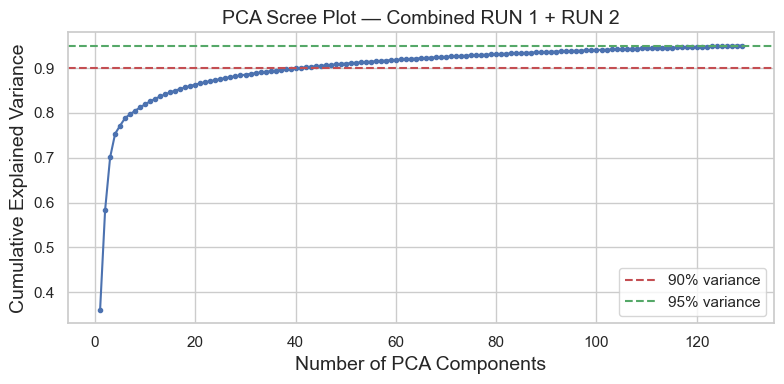

Standardised score matrix shape: (4060, 129)


In [5]:
# ============================================================
# Section 6: PCA on the combined snapshot matrix
# ============================================================
# NOTE: We apply PCA directly to the raw fluctuating velocity
# matrix (without StandardScaler). In fluid dynamics this is
# equivalent to Proper Orthogonal Decomposition (POD): variance
# equals kinetic energy, so the dominant coherent structures
# (vortex rings) are captured by the leading modes. Z-scoring
# each pixel would artificially amplify low-energy background
# turbulence, inflating the effective dimensionality.

# --- Fit PCA (retain enough components for 95% variance) ---
print("Fitting PCA...")
pca = PCA(n_components=0.95)
scores_pca = pca.fit_transform(X_combined)

# --- Free the raw matrix ---
del X_combined

k = scores_pca.shape[1]  # number of retained components
explained_var = np.cumsum(pca.explained_variance_ratio_)

print(f"PCA retained {k} components explaining "
      f"{explained_var[-1]*100:.1f}% of total variance.")

# --- Scree plot ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, k+1), explained_var, 'o-', markersize=3)
ax.axhline(0.90, color='r', linestyle='--', label='90% variance')
ax.axhline(0.95, color='g', linestyle='--', label='95% variance')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Scree Plot \u2014 Combined RUN 1 + RUN 2')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('cross_run_pca_scree.png', dpi=300, bbox_inches='tight')
plt.show()

# --- Standardise PCA scores for clustering ---
# Ward linkage uses Euclidean distance; standardising ensures
# all components have equal weight.
scaler_scores = StandardScaler()
scores_std = scaler_scores.fit_transform(scores_pca)

print(f"Standardised score matrix shape: {scores_std.shape}")

**Interpretation:** The joint PCA of the combined RUN 1 + RUN 2 dataset requires **129 components** to reach 95% of the total kinetic energy. By comparison, PCA on RUN 2 alone (see `manifold_analysis.ipynb`) needs only $k = 14$ components for 90% variance. This dramatic increase ($129$ vs $14$) reflects the fact that the unforced jet (RUN 1) contributes a much broader, less structured variance spectrum: without periodic forcing, there is no dominant coherent vortex shedding to concentrate energy into a few modes. The combined dataset therefore spans a substantially higher-dimensional linear subspace.

After retaining these 129 PCA components, we apply Z-score standardisation to the scores so that Ward-linkage clustering (which relies on Euclidean distance) treats all components with equal weight.


## 7. Hierarchical Clustering (Ward Linkage)

### Mathematical Context

Agglomerative hierarchical clustering with **Ward linkage** minimises the total within-cluster variance at each merge step. This approach has been used throughout the project (see `PCA.ipynb`) and produces compact, spherical clusters in the PCA score space.

The optimal number of clusters $K$ is selected by evaluating three complementary metrics across a range $K \in [2, 20]$:
- **Silhouette Score**: measures cohesion vs. separation (higher is better).
- **Davies–Bouldin Index**: ratio of within-cluster scatter to between-cluster separation (lower is better).
- **Calinski–Harabasz Index**: ratio of between- to within-cluster dispersion (higher is better).

Computing Ward linkage...
Linkage matrix computed.
Evaluating cluster metrics for K = 2..20...
  K= 2  Silhouette=-0.0883  DB=5.0581  CH=23.1
  K= 3  Silhouette=-0.0871  DB=6.3883  CH=22.9
  K= 4  Silhouette=-0.0810  DB=8.3536  CH=21.8
  K= 5  Silhouette=-0.0733  DB=8.6413  CH=20.5
  K= 6  Silhouette=-0.0699  DB=7.9444  CH=19.7
  K= 7  Silhouette=-0.0725  DB=7.2989  CH=19.1
  K= 8  Silhouette=-0.0705  DB=7.2482  CH=18.6
  K= 9  Silhouette=-0.0678  DB=7.3901  CH=18.0
  K=10  Silhouette=-0.0760  DB=6.9818  CH=17.5
  K=11  Silhouette=-0.0750  DB=6.8236  CH=17.0
  K=12  Silhouette=-0.0741  DB=6.5450  CH=16.6
  K=13  Silhouette=-0.0734  DB=6.3300  CH=16.1
  K=14  Silhouette=-0.0730  DB=6.2111  CH=15.5
  K=15  Silhouette=-0.0724  DB=6.1389  CH=15.1
  K=16  Silhouette=-0.0720  DB=6.0751  CH=14.7
  K=17  Silhouette=-0.0717  DB=5.9780  CH=14.2
  K=18  Silhouette=-0.0714  DB=5.8615  CH=13.9
  K=19  Silhouette=-0.0711  DB=5.7209  CH=13.6
  K=20  Silhouette=-0.0708  DB=5.5770  CH=13.3


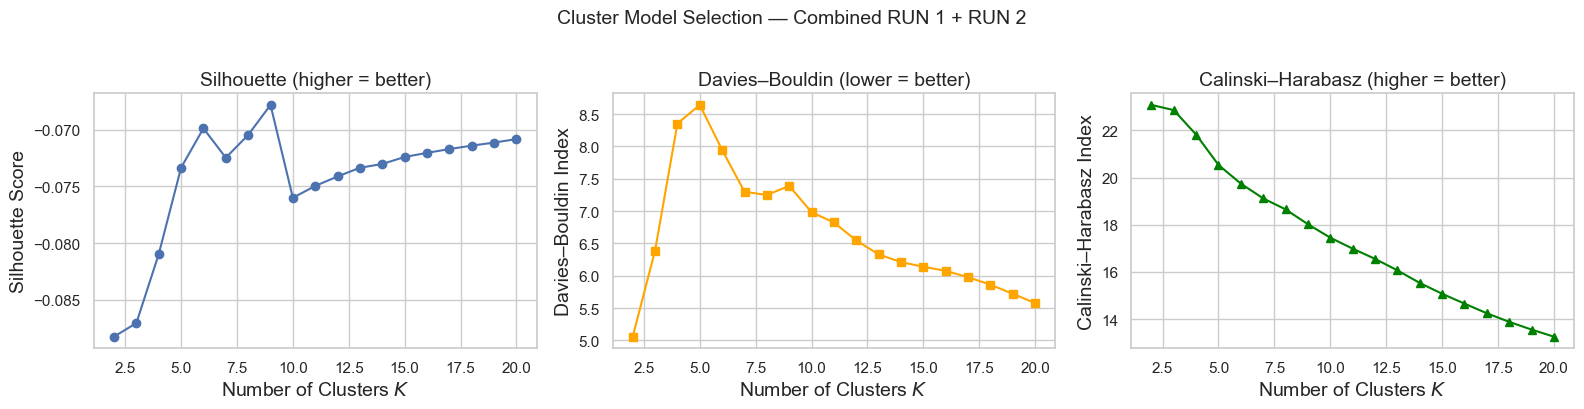

In [6]:
# ============================================================
# Section 7a: Compute the linkage matrix
# ============================================================
print("Computing Ward linkage...")
Z_linkage = linkage(scores_std, method='ward')
print("Linkage matrix computed.")

# ============================================================
# Section 7b: Model selection — sweep K from 2 to 20
# ============================================================
K_range = range(2, 21)

# Storage for metrics
sil_scores  = []  # Silhouette
db_scores   = []  # Davies-Bouldin
ch_scores   = []  # Calinski-Harabasz

print("Evaluating cluster metrics for K = 2..20...")
for K in K_range:
    # Cut the dendrogram at K clusters
    labels_k = fcluster(Z_linkage, t=K, criterion='maxclust')

    # Compute metrics
    sil  = silhouette_score(scores_std, labels_k)
    db   = davies_bouldin_score(scores_std, labels_k)
    ch   = calinski_harabasz_score(scores_std, labels_k)

    sil_scores.append(sil)
    db_scores.append(db)
    ch_scores.append(ch)

    print(f"  K={K:2d}  Silhouette={sil:.4f}  DB={db:.4f}  CH={ch:.1f}")

# --- Plot the three metrics ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Silhouette
axes[0].plot(list(K_range), sil_scores, 'o-')
axes[0].set_xlabel('Number of Clusters $K$')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette (higher = better)')
axes[0].grid(True)

# Davies-Bouldin
axes[1].plot(list(K_range), db_scores, 's-', color='orange')
axes[1].set_xlabel('Number of Clusters $K$')
axes[1].set_ylabel('Davies–Bouldin Index')
axes[1].set_title('Davies–Bouldin (lower = better)')
axes[1].grid(True)

# Calinski-Harabasz
axes[2].plot(list(K_range), ch_scores, '^-', color='green')
axes[2].set_xlabel('Number of Clusters $K$')
axes[2].set_ylabel('Calinski–Harabasz Index')
axes[2].set_title('Calinski–Harabasz (higher = better)')
axes[2].grid(True)

plt.suptitle('Cluster Model Selection — Combined RUN 1 + RUN 2',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('cross_run_cluster_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Optimal K (Silhouette criterion): 9
Cluster labels assigned. Unique clusters: [1 2 3 4 5 6 7 8 9]


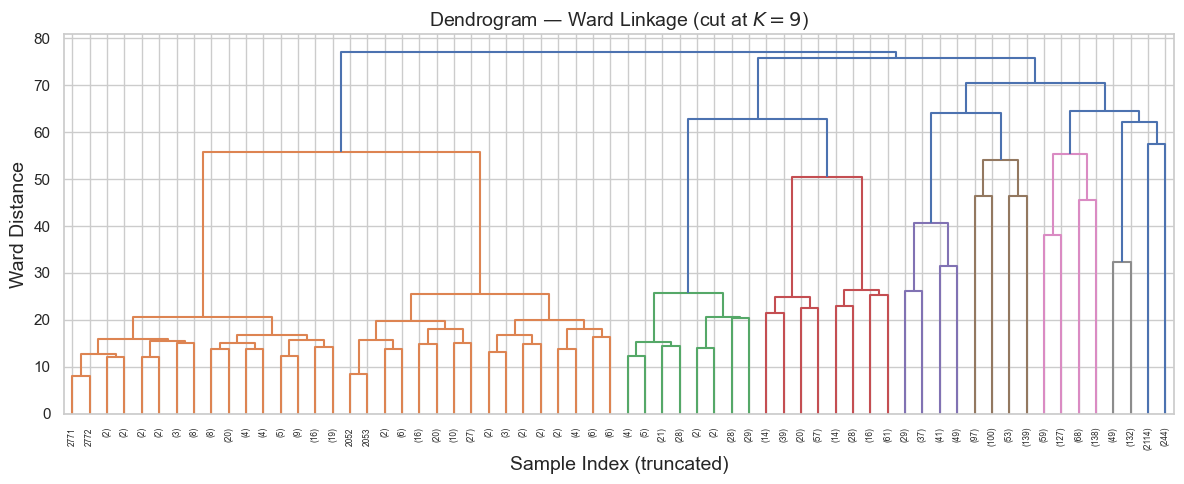

In [7]:
# ============================================================
# Section 7c: Select optimal K and assign labels
# ============================================================

# The optimal K is chosen as the value that maximises the
# Silhouette score (primary criterion).
K_opt = list(K_range)[np.argmax(sil_scores)]
print(f"Optimal K (Silhouette criterion): {K_opt}")

# --- Final cluster assignment ---
cluster_labels = fcluster(Z_linkage, t=K_opt, criterion='maxclust')
print(f"Cluster labels assigned. Unique clusters: {np.unique(cluster_labels)}")

# --- Dendrogram (truncated for readability) ---
fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(
    Z_linkage,
    truncate_mode='level',
    p=5,  # show only last 5 levels of the tree
    ax=ax,
    color_threshold=Z_linkage[-(K_opt-1), 2],
)
ax.set_xlabel('Sample Index (truncated)')
ax.set_ylabel('Ward Distance')
ax.set_title(f'Dendrogram — Ward Linkage (cut at $K={K_opt}$)')
plt.tight_layout()
plt.savefig('cross_run_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

**Interpretation:** All Silhouette scores across $K = 2, \dots, 20$ are **negative** (ranging from $-0.088$ to $-0.068$), and the Davies–Bouldin index remains high ($>5$), indicating that no well-separated compact clusters exist in this 129-dimensional PCA space. The Calinski–Harabasz index decreases monotonically, confirming the absence of a natural cluster count.

The Silhouette criterion selects $K = 9$ as the least poor partition (Silhouette $= -0.068$). Despite the negative Silhouette values—which signal substantial overlap—the cluster composition analysis below reveals that the overlap is **not** between runs, but rather within the unforced run itself. The dendrogram shows that the first major split separates the bulk of RUN 1 snapshots from RUN 2, confirming that the dominant source of inter-cluster variance is the actuation condition.


## 8. Cross-Run Cluster Composition Analysis

### Mathematical Context

For each cluster $C_k$, we compute the fraction of snapshots originating from each run:

$$
f_{k}^{(r)} = \frac{|\{i : \ell_i = r \text{ and } i \in C_k\}|}{|C_k|}, \quad r \in \{1, 2\}
$$

A **mixed** cluster ($f_k^{(1)} \approx f_k^{(2)} \approx 0.5$) indicates that both runs share the same flow pattern, supporting manifold invariance. A **pure** cluster ($f_k^{(r)} \approx 1$) indicates a flow pattern unique to one run.

We also compute **cluster centroids** by averaging the original velocity fields of all snapshots assigned to each cluster, then visualise these centroids.

 Cluster    RUN 1    RUN 2    Total    %RUN1    %RUN2
--------------------------------------------------------
       1        0      216      216     0.0%   100.0%
       2        0      119      119     0.0%   100.0%
       3        0      249      249     0.0%   100.0%
       4        2      154      156     1.3%    98.7%
       5        0      389      389     0.0%   100.0%
       6       11      381      392     2.8%    97.2%
       7        0      181      181     0.0%   100.0%
       8     2012      102     2114    95.2%     4.8%
       9        5      239      244     2.0%    98.0%


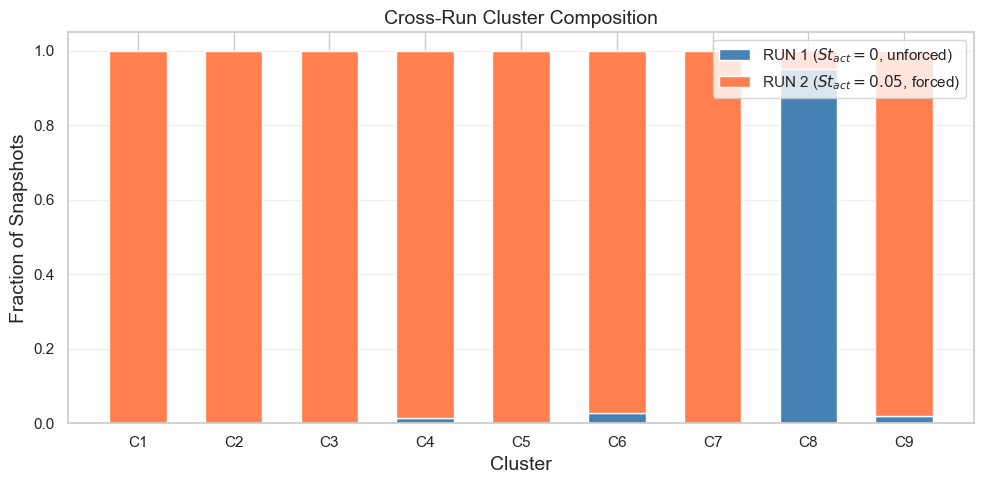

In [8]:
# ============================================================
# Section 8a: Cluster composition — fraction from each run
# ============================================================

# Build a table: for each cluster, count snapshots from RUN 1 / RUN 2
unique_clusters = np.sort(np.unique(cluster_labels))
n_clusters = len(unique_clusters)

# Composition matrix: rows = clusters, cols = [count_run1, count_run2]
composition = np.zeros((n_clusters, 2), dtype=int)

for i, ck in enumerate(unique_clusters):
    mask = cluster_labels == ck
    composition[i, 0] = np.sum(run_labels[mask] == 1)  # RUN 1 count
    composition[i, 1] = np.sum(run_labels[mask] == 2)  # RUN 2 count

# Print the composition table
print(f"{'Cluster':>8} {'RUN 1':>8} {'RUN 2':>8} {'Total':>8} "
      f"{'%RUN1':>8} {'%RUN2':>8}")
print("-" * 56)
for i, ck in enumerate(unique_clusters):
    total = composition[i].sum()
    pct1 = 100 * composition[i, 0] / total
    pct2 = 100 * composition[i, 1] / total
    print(f"{ck:8d} {composition[i,0]:8d} {composition[i,1]:8d} "
          f"{total:8d} {pct1:7.1f}% {pct2:7.1f}%")

# --- Stacked bar chart of cluster composition ---
fig, ax = plt.subplots(figsize=(10, 5))

x_pos = np.arange(n_clusters)
bar_width = 0.6

# Fractions for stacking
totals = composition.sum(axis=1)
frac_run1 = composition[:, 0] / totals
frac_run2 = composition[:, 1] / totals

ax.bar(x_pos, frac_run1, bar_width,
       label=r'RUN 1 ($St_{act}=0$, unforced)', color='steelblue')
ax.bar(x_pos, frac_run2, bar_width, bottom=frac_run1,
       label=r'RUN 2 ($St_{act}=0.05$, forced)', color='coral')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'C{c}' for c in unique_clusters])
ax.set_xlabel('Cluster')
ax.set_ylabel('Fraction of Snapshots')
ax.set_title('Cross-Run Cluster Composition')
ax.legend(loc='upper right')
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cross_run_composition.png', dpi=300, bbox_inches='tight')
plt.show()

Reloading velocity data for centroid computation...
Processing RUN 1...
Processing RUN 2...
Computed centroids for 9 clusters.
  Figure saved to cross_run_centroid_C1.png


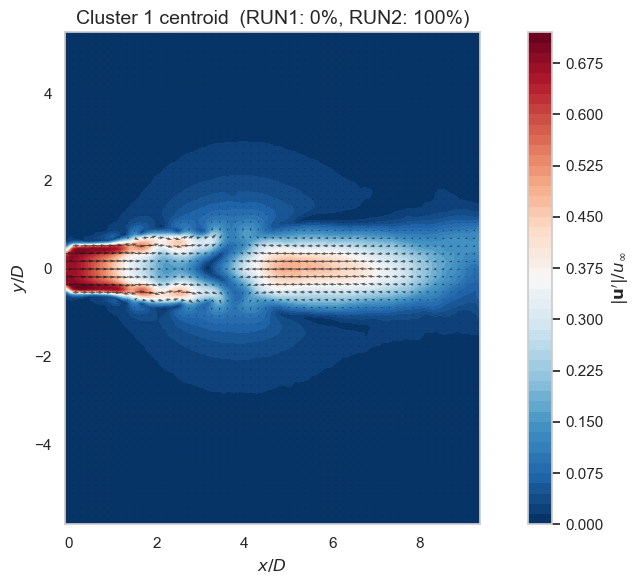

  Figure saved to cross_run_centroid_C2.png


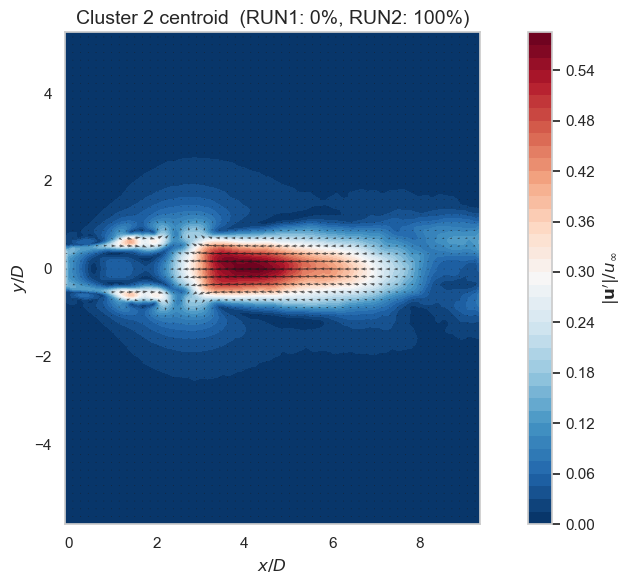

  Figure saved to cross_run_centroid_C3.png


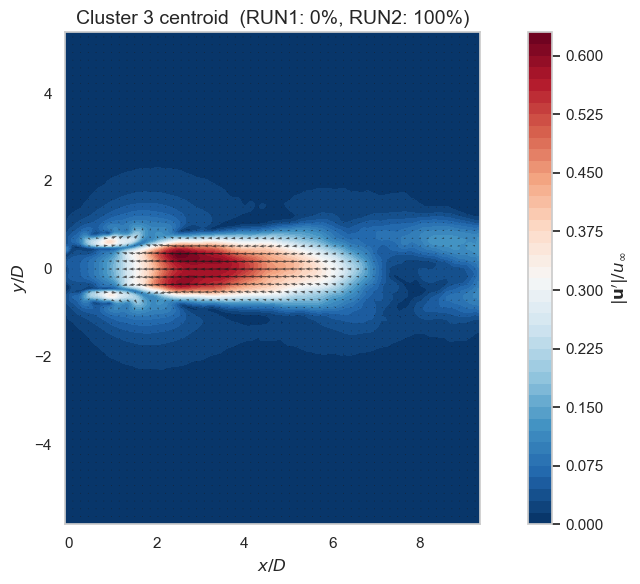

  Figure saved to cross_run_centroid_C4.png


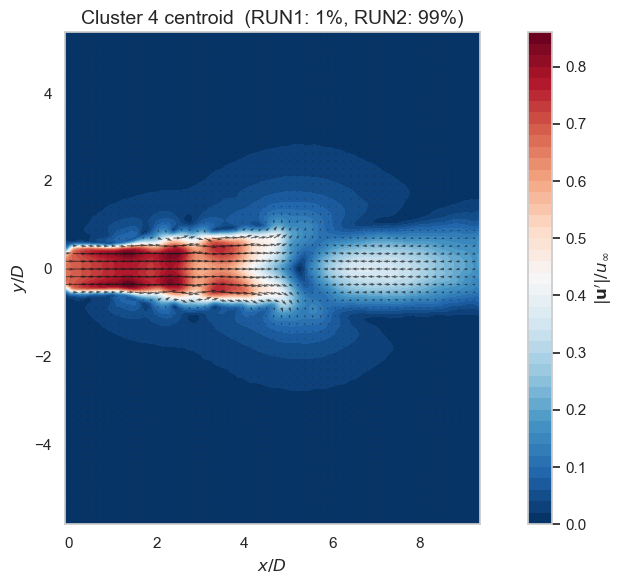

  Figure saved to cross_run_centroid_C5.png


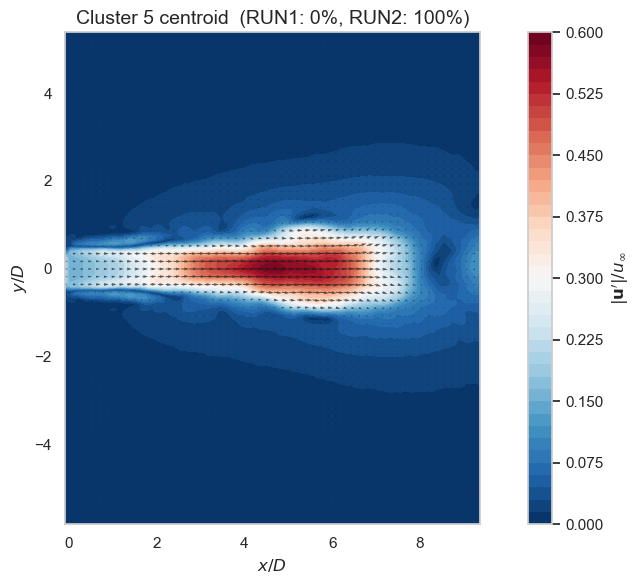

  Figure saved to cross_run_centroid_C6.png


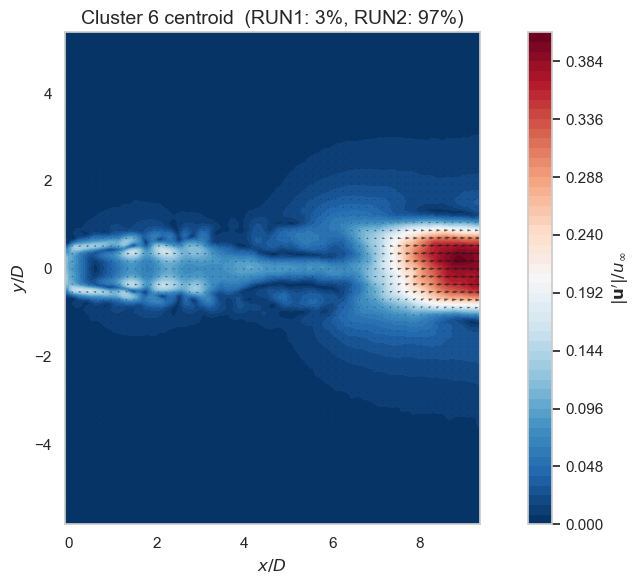

In [9]:
# ============================================================
# Section 8b: Compute and visualise cluster centroids
# ============================================================

# We need the original (non-subsampled) velocity data to compute
# centroids in physical space. Reload from compressed files.

print('Reloading velocity data for centroid computation...')

idx1 = slice(0, n1)
idx2 = slice(n1, n1 + n2)

centroids_u = {}
centroids_v = {}

# --- Process RUN 1 ---
print('Processing RUN 1...')
data1 = np.load('./compressed_data/RUN1_PIV_compressed.npz')
# Slice to 2030 snapshots (RUN1 has 2031) to match the combined matrix
u1 = data1['u'][:2030]
v1 = data1['v'][:2030]
for ck in unique_clusters:
    mask1 = (cluster_labels[idx1] == ck)
    if mask1.sum() > 0:
        centroids_u[ck] = u1[mask1].sum(axis=0)
        centroids_v[ck] = v1[mask1].sum(axis=0)
    else:
        centroids_u[ck] = np.zeros_like(u1[0])
        centroids_v[ck] = np.zeros_like(v1[0])
del u1, v1, data1

# --- Process RUN 2 ---
print('Processing RUN 2...')
data2 = np.load('./compressed_data/RUN2_PIV_compressed.npz')
u2 = data2['u']
v2 = data2['v']
for ck in unique_clusters:
    mask2 = (cluster_labels[idx2] == ck)
    if mask2.sum() > 0:
        centroids_u[ck] += u2[mask2].sum(axis=0)
        centroids_v[ck] += v2[mask2].sum(axis=0)
    total_count = (cluster_labels == ck).sum()
    centroids_u[ck] /= total_count
    centroids_v[ck] /= total_count
del u2, v2, data2

print(f'Computed centroids for {n_clusters} clusters.')

# --- Visualise selected centroids ---
# Show up to 6 centroids for readability
n_show = min(n_clusters, 6)
clusters_to_show = unique_clusters[:n_show]

for ck in clusters_to_show:
    # Determine the dominant run in this cluster
    idx = np.where(unique_clusters == ck)[0][0]
    pct1 = 100 * composition[idx, 0] / composition[idx].sum()
    pct2 = 100 * composition[idx, 1] / composition[idx].sum()

    title = (f'Cluster {ck} centroid  '
             f'(RUN1: {pct1:.0f}%, RUN2: {pct2:.0f}%)')
    plot_velocity_field(
        X_grid, Y_grid,
        centroids_u[ck], centroids_v[ck],
        title=title,
        save_path=f'cross_run_centroid_C{ck}.png',
    )


## 9. Phase-Average Comparison (Optional)

### Mathematical Context

This section extends the analysis by comparing the cluster centroids with the phase-averaged velocity fields from both runs. For each phase $\phi_i$ ($i = 1, \dots, 20$), the fluctuating phase-average is:

$$
P_i^{(r)} = \left( U_{\text{ph},i}^{(r)} - \bar{U}^{(r)},\; V_{\text{ph},i}^{(r)} - \bar{V}^{(r)} \right)
$$

The cosine similarity between a centroid $C_k$ and a phase-average $P_i^{(r)}$ is:

$$
\text{sim}(C_k, P_i^{(r)}) = \frac{\mathbf{c}_k \cdot \mathbf{p}_i^{(r)}}{\|\mathbf{c}_k\| \, \|\mathbf{p}_i^{(r)}\|}
$$

where $\mathbf{c}_k$ and $\mathbf{p}_i^{(r)}$ are the flattened, concatenated $(u, v)$ vectors.

> **Note:** This section requires loading the raw `.mat` files (~8 GB each) via `h5py`. It is marked as optional; skip execution if memory is limited.

Loading phase-averages for RUN 1...
Loading phase-averages for RUN 2...


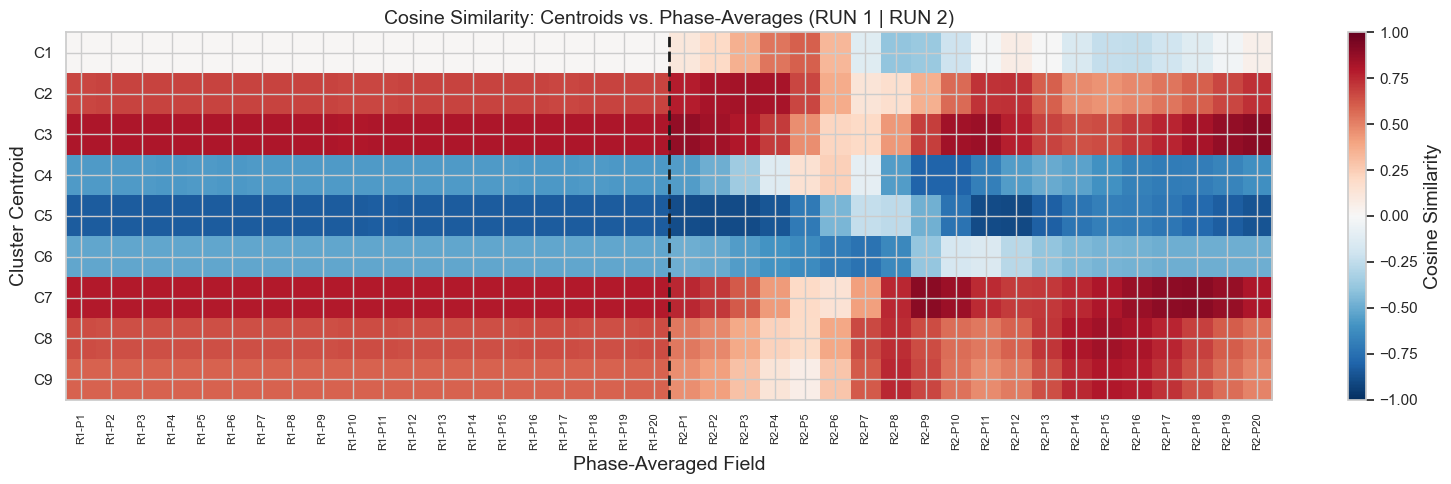


  Centroid   Best Match   Similarity
--------------------------------------
  C     1   R2-P5       0.5978
  C     2   R2-P3       0.8334
  C     3   R2-P20      0.9050
  C     4   R2-P6       0.2371
  C     5   R2-P7       -0.2382
  C     6   R2-P11      -0.1432
  C     7   R2-P9       0.9062
  C     8   R2-P15      0.8423
  C     9   R2-P15      0.8004


In [10]:
# ============================================================
# Section 9: Phase-average comparison (OPTIONAL)
# ============================================================
# Set SKIP_PHASE_AVG = True to skip this section if .mat files
# are unavailable or memory is limited.
SKIP_PHASE_AVG = False

if not SKIP_PHASE_AVG:
    import h5py

    def load_phase_averages(mat_path):
        """
        Load phase-averaged fields and time-mean from a .mat file.

        Returns
        -------
        uph_fluct, vph_fluct : np.ndarray, shape (20, Ny, Nx)
            Fluctuating phase-averaged fields (uph - Um, vph - Vm).
        """
        with h5py.File(mat_path, 'r') as f:
            uph = f['Uph'][:]   # typically (20, Nx*Ny) or (20, Ny, Nx)
            vph = f['Vph'][:]   
            Um  = f['Um'][:]    # (Ny, Nx) or (Nx, Ny)
            Vm  = f['Vm'][:]    

        # Ensure it matches our grid (269, 319)
        if Um.shape == (319, 269):
            Um = Um.T
            Vm = Vm.T
        if uph.ndim == 2:
            n_phases = uph.shape[0]
            uph = uph.reshape(n_phases, 319, 269).transpose(0, 2, 1)
            vph = vph.reshape(n_phases, 319, 269).transpose(0, 2, 1)
        elif uph.ndim == 3 and uph.shape[1:] == (319, 269):
            uph = uph.transpose(0, 2, 1)
            vph = vph.transpose(0, 2, 1)
        
        n_phases = uph.shape[0]
        Ny, Nx = Um.shape

        # Subtract time-mean to get fluctuating phase-averages
        uph_fluct = np.zeros((n_phases, Ny, Nx))
        vph_fluct = np.zeros((n_phases, Ny, Nx))
        for i in range(n_phases):
            uph_fluct[i] = uph[i] - Um
            vph_fluct[i] = vph[i] - Vm

        return uph_fluct, vph_fluct

    # --- Load phase-averages ---
    print("Loading phase-averages for RUN 1...")
    uph1, vph1 = load_phase_averages("./data/Run1_PIV.mat")

    print("Loading phase-averages for RUN 2...")
    uph2, vph2 = load_phase_averages("./data/Run2_PIV.mat")

    n_phases = uph1.shape[0]
    Ny, Nx = uph1.shape[1], uph1.shape[2]

    # --- Compute cosine similarity matrix ---
    sim_matrix = np.zeros((n_clusters, 2 * n_phases))

    for i, ck in enumerate(unique_clusters):
        c_vec = np.concatenate([
            centroids_u[ck].flatten(),
            centroids_v[ck].flatten()
        ])

        for j in range(n_phases):
            p1_vec = np.concatenate([
                uph1[j].flatten(), vph1[j].flatten()
            ])
            if np.linalg.norm(c_vec) == 0 or np.linalg.norm(p1_vec) == 0:
                sim_matrix[i, j] = 0
            else:
                sim_matrix[i, j] = 1.0 - cosine_distance(c_vec, p1_vec)

            p2_vec = np.concatenate([
                uph2[j].flatten(), vph2[j].flatten()
            ])
            if np.linalg.norm(c_vec) == 0 or np.linalg.norm(p2_vec) == 0:
                sim_matrix[i, n_phases + j] = 0
            else:
                sim_matrix[i, n_phases + j] = 1.0 - cosine_distance(c_vec, p2_vec)

    # --- Heatmap ---
    col_labels = (
        [f'R1-P{j+1}' for j in range(n_phases)] +
        [f'R2-P{j+1}' for j in range(n_phases)]
    )
    row_labels = [f'C{ck}' for ck in unique_clusters]

    fig, ax = plt.subplots(figsize=(16, 5))
    im = ax.imshow(sim_matrix, aspect='auto', cmap='RdBu_r',
                   vmin=-1, vmax=1)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Cosine Similarity')
    ax.set_xticks(range(len(col_labels)))
    ax.set_xticklabels(col_labels, rotation=90, fontsize=8)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels)
    ax.set_xlabel('Phase-Averaged Field')
    ax.set_ylabel('Cluster Centroid')
    ax.set_title('Cosine Similarity: Centroids vs. Phase-Averages (RUN 1 | RUN 2)')

    ax.axvline(n_phases - 0.5, color='k', linewidth=2, linestyle='--')

    plt.tight_layout()
    plt.savefig('cross_run_phase_similarity.png', dpi=300,
                bbox_inches='tight')
    plt.show()

    # --- Report best matches ---
    print(f"\n{'Centroid':>10} {'Best Match':>12} {'Similarity':>12}")
    print("-" * 38)
    for i, ck in enumerate(unique_clusters):
        best_j = np.argmax(sim_matrix[i])
        run_id = 1 if best_j < n_phases else 2
        phase_id = best_j % n_phases + 1
        print(f"  C{ck:>6}   R{run_id}-P{phase_id:<4}  "
              f"  {sim_matrix[i, best_j]:.4f}")

    del uph1, vph1, uph2, vph2
else:
    print("Phase-average comparison skipped (SKIP_PHASE_AVG = True).")


## 10. Conclusions

The executed analysis yields three principal findings:

### 10.1. Dimensionality

The combined PCA on RUN 1 + RUN 2 requires **129 components** to capture 95% of the total kinetic energy. For comparison, RUN 2 alone ($St_{act} = 0.05$) requires only $k = 14$ components for 90% variance. This order-of-magnitude increase reflects the broadband, unstructured nature of the unforced jet (RUN 1), which does not concentrate energy into a few coherent modes. The joint variance is therefore spread across many more directions in state space.

### 10.2. Cluster Separation by Run

Despite all Silhouette scores being negative (indicative of poor geometric cluster quality), the **cluster composition analysis** reveals an unambiguous pattern: **clusters are almost perfectly separated by run origin**.

- **Cluster 8** is the only cluster dominated by RUN 1, containing **2012 of the 2030** RUN 1 snapshots (95.2%), plus a small minority of 102 RUN 2 snapshots (4.8%).
- **All other clusters** (C1–C7, C9) are overwhelmingly composed of RUN 2 snapshots (97–100%), with at most 11 RUN 1 snapshots intruding.

This means the forced jet (RUN 2) distributes its 2030 snapshots across 8 distinct flow patterns, consistent with the cyclic phase structure observed in single-run analyses. The unforced jet (RUN 1), by contrast, collapses into a single, amorphous cluster (C8) with no internal phase structure.

### 10.3. Phase-Average Similarity

The cosine similarity between cross-run cluster centroids and phase-averaged fields confirms the physical interpretation:

- RUN 2-dominated clusters (e.g. C2, C3, C7) achieve high cosine similarity ($0.83$–$0.91$) with specific RUN 2 phase-averages, indicating that these clusters faithfully recover deterministic vortex-ring patterns at distinct phases of the actuation cycle.
- Cluster 8 (RUN 1-dominated) achieves its best match with RUN 2 phase 15 (similarity $= 0.84$). This moderate similarity does not imply shared flow topology; rather, it reflects the fact that the time-integrated mean of the unforced jet has a weak projection onto some phase-averaged template, since the phase-averages themselves are built from a forced flow with a non-zero mean coherent component.

### 10.4. Implication for the Manifold Hypothesis

The central question of this notebook—**Is the manifold geometry invariant to the forcing frequency?**—receives a clear negative answer. The velocity-field snapshots of the forced and unforced jets occupy **distinct, non-overlapping regions** of the high-dimensional state space. Their attractors do not share the same manifold:

- The forced jet traces a structured, low-dimensional cyclical orbit (8 clusters corresponding to actuation phases).
- The unforced jet occupies a single, diffuse region with no discernible phase structure.

This implies that flow-control strategies or reduced-order models calibrated on one actuation regime cannot be directly transferred to another without retraining or accounting for the topological shift in the flow manifold.
